# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load your uploaded file (path "/content/listings.csv.gz")
df = pd.read_csv("/content/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,360,https://www.airbnb.com/rooms/360,20260630053644,2026-06-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,NaN,https://a0.muscache.com/pictures/monet/Select-...,666,...,4.99,4.98,4.90,2017-BFN-0002177,NaN,1,1,0,0,1.94
1,364,https://www.airbnb.com/rooms/364,20260630053644,2026-07-02,previous scrape,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of ...",NaN,https://a0.muscache.com/pictures/11766413/a2c5...,783,...,4.96,4.65,4.71,NaN,NaN,1,1,0,0,0.42
2,592,https://www.airbnb.com/rooms/592,20260630053644,2026-06-30,city scrape,private,This room is in the basement. It does not hav...,NaN,https://a0.muscache.com/pictures/ba522ff9-84c9...,933,...,4.96,4.84,4.88,2021-BFN-0000578,NaN,1,0,1,0,1.05
3,686,https://www.airbnb.com/rooms/686,20260630053644,2026-06-30,city scrape,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG...,NaN,https://a0.muscache.com/pictures/108112/e6d5d3...,990,...,4.91,4.87,4.82,NaN,NaN,1,0,1,0,1.16
4,1940,https://www.airbnb.com/rooms/1940,20260630053644,2026-06-30,city scrape,"Baker Studio Pet-friendly, Walkable, Patio",Private studio retreat in a charming historic ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,2150,...,4.99,4.90,4.90,2018-BFN-0002596,NaN,2,2,0,0,2.42


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

neighborhood_overview           4939
host_since                      4939
host_response_time              4939
host_thumbnail_url              4939
host_acceptance_rate            4939
host_response_rate              4939
host_verifications              4939
neighbourhood                   4939
host_total_listings_count       4939
host_neighbourhood              4939
calendar_updated                4939
instant_bookable                4939
neighbourhood_group_cleansed    4939
host_about                      1945
license                         1773
bathrooms                        887
host_location                    768
beds                             728
price                            688
price_quote_price_per_night      688
dtype: int64


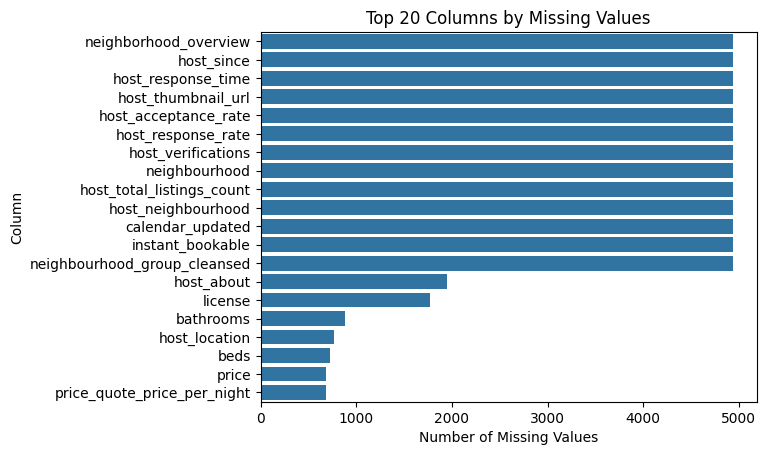

In [3]:
# Count missing values in each column and chart the top 20
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

sns.barplot(x=missing.head(20).values, y=missing.head(20).index)
plt.title('Top 20 Columns by Missing Values')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response:
1. A bunch of columns tie for the most. 13 columns are missing all 4,939 rows, like neighborhood_overview, host_since, and host_response_time. After those, host_about is missing 1,945 and license is missing 1,773.

2. Price is the big one. It's missing in 688 listings, and you can't compare or map prices for a listing that has no price. Bathrooms is missing 887 and beds is missing 728, which makes it harder to compare listings to each other.

3. The 13 columns that are completely empty can be dropped since there's nothing in them. host_about is just a text blurb about the host, so that one can be ignored too.

## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [4]:
# Drop columns that are empty or the same in every row
df = df.drop(columns=['neighbourhood_group_cleansed', 'calendar_updated', 'host_thumbnail_url', 'scrape_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4939 non-null   int64  
 1   listing_url                                   4939 non-null   object 
 2   last_scraped                                  4939 non-null   object 
 3   source                                        4939 non-null   object 
 4   name                                          4939 non-null   object 
 5   description                                   4904 non-null   object 
 6   neighborhood_overview                         0 non-null      float64
 7   picture_url                                   4939 non-null   object 
 8   host_id                                       4939 non-null   int64  
 9   host_url                                      4939 non-null   o

### Reflection: 
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response:
1. I dropped neighbourhood_group_cleansed, calendar_updated, host_thumbnail_url, and scrape_id.

2. The first three are empty in every row, so there's nothing to learn from them. scrape_id is the same number on every row because it's just the ID for when the data was pulled, so it doesn't say anything about a listing.

3. They make the dataset bigger and harder to read for no reason. Someone could also waste time trying to use an empty column in a chart and end up with errors or a blank result.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [5]:
# Fill missing values in two columns
print("Median rating:", df['review_scores_rating'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())
df['host_location'] = df['host_location'].fillna('Unknown')
print(df[['review_scores_rating', 'host_location']].isnull().sum())

Median rating: 4.94
review_scores_rating    0
host_location           0
dtype: int64


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response:
1. review_scores_rating and host_location.

2. For review_scores_rating I filled the blanks with the median, which is 4.94. I used the median because most scores are bunched up near 5, and a few really low ones would pull the average down. For host_location I filled the blanks with "Unknown" because it's text and I didn't want to guess where a host lives.

3. The listings with no rating are probably ones that haven't been reviewed yet, so giving them a 4.94 makes them look like great listings when nobody has actually rated them. "Unknown" is safer, but now it shows up like it's a real place, so it would have to be filtered out of any chart by location.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [6]:
# Convert price from text to a number
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)
df['price'].describe()

count      4251.000000
mean        276.042277
std        1753.134720
min           7.380000
25%         105.995000
50%         176.450000
75%         291.000000
max      110616.600000
Name: price, dtype: float64

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response:
1. price.

2. It was stored as text because every price had a dollar sign in front, and the bigger ones had commas. I took out the dollar signs and commas with str.replace and then changed the column to a float. Then I ran describe to make sure it worked.

3. Now price works in math, so it can be averaged, sorted, and charted. The describe output already showed something I couldn't see before. The middle price is about 176 a night, but the highest is 110,616.60, which has to be a mistake or a fake listing.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates 
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs 
- Remove duplicates if found 

In [7]:
# Check for duplicate rows and duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df['id'].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response:
1. No. There were 0 duplicate rows and 0 duplicate IDs.

2. Since there weren't any, I didn't drop anything. If there had been exact copies, I'd keep the first one and drop the rest. If two rows had the same ID but different values, I'd look at them before picking one.

3. A listing that's counted twice makes it look like there are more places to rent than there really are, and it doubles that listing's revenue in any total. A guest could also see the same place twice when they search.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”) 
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP 
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP 

```





In [8]:
# Export the cleaned data
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts? 
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information) 
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response:

1. Section 4 was the hardest. The code was only a couple of lines, but deciding what to fill in was tough. It was more about the class concepts than the coding, since I had to think about whether the median was fair for listings with no reviews.
2. I had to fix price. It was saved as text with dollar signs and commas, so I couldn't do any math with it. Price is the main thing anyone looking at Airbnb data cares about, so it had to be a real number.
3. A pricing analyst could compare prices across neighborhoods and room types now that price is a number. A host could also see what similar listings near them charge.
4. I'd drop the other 10 empty columns, look into the 688 listings with no price, and figure out what's going on with the 110,616.60 listing. I'd also try flagging listings with no reviews instead of filling in the median.
5. One of my learning outcomes is a before and after case study for my dental clients using things like show rates and cost per lead. The before numbers come from the client's old agency and the after numbers come from my own dashboard, so they won't be set up the same way. This assignment showed me I need to check for blanks, numbers saved as text, and duplicates before I compare anything, or the case study could be wrong.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"